In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Datasets

house_df = pd.read_csv("data/house_prices.csv")
churn_df = pd.read_csv("data/customer_churn.csv")
sales_df = pd.read_csv("data/sales_data.csv")

print(house_df.head())
print(churn_df.head())
print(sales_df.head())

  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  

In [3]:
# Dataset Information

print(house_df.info())
print(churn_df.info())
print(sales_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non

In [4]:
# Missing Values

print(house_df.isnull().sum())
print(churn_df.isnull().sum())
print(sales_df.isnull().sum())

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [5]:
# Remove Duplicates

house_df.drop_duplicates(inplace=True)
churn_df.drop_duplicates(inplace=True)
sales_df.drop_duplicates(inplace=True)

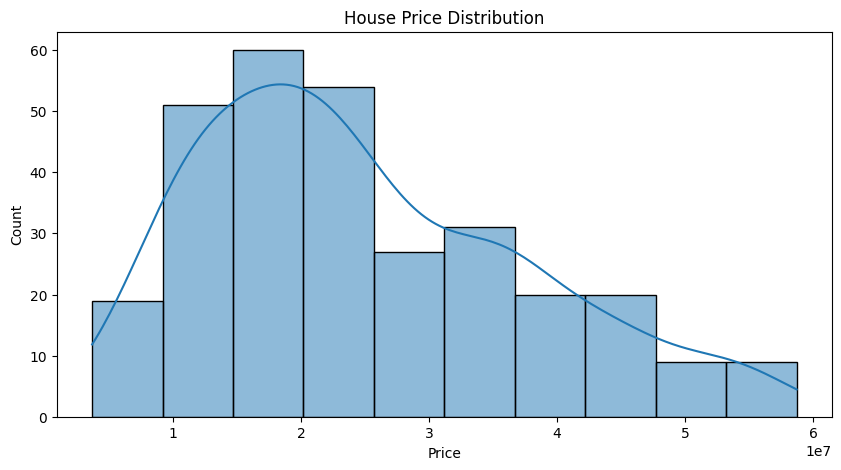

In [6]:
# House Price Distribution

plt.figure(figsize=(10,5))

sns.histplot(house_df['Price'], kde=True)

plt.title("House Price Distribution")

plt.show()

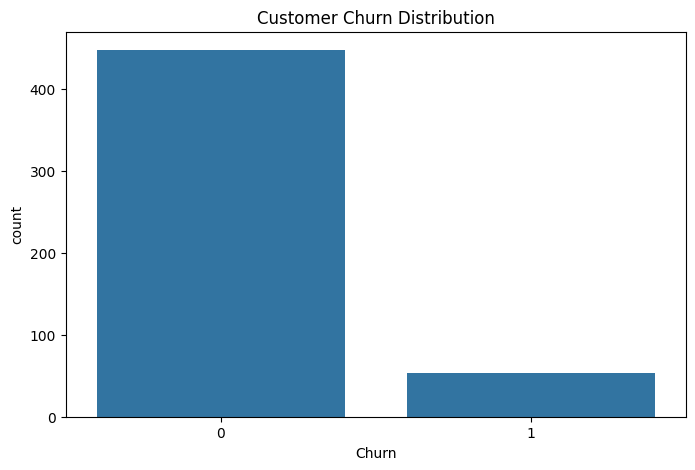

In [7]:
# Customer Churn Distribution

plt.figure(figsize=(8,5))

sns.countplot(x='Churn', data=churn_df)

plt.title("Customer Churn Distribution")

plt.show()

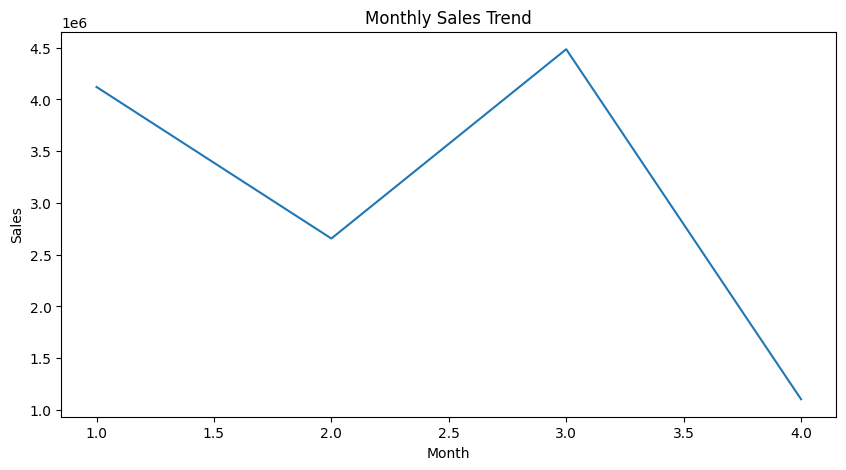

In [8]:
# Sales Trend Analysis

sales_df['Date'] = pd.to_datetime(sales_df['Date'])

monthly_sales = sales_df.groupby(
    sales_df['Date'].dt.month
)['Total_Sales'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [9]:
# Feature Engineering

le = LabelEncoder()

# House Dataset

if 'Location' in house_df.columns:
    house_df['Location'] = le.fit_transform(house_df['Location'])

if 'Property_Type' in house_df.columns:
    house_df['Property_Type'] = le.fit_transform(house_df['Property_Type'])

# Churn Dataset

for col in churn_df.select_dtypes(include='object').columns:
    
    if col != 'CustomerID':
        churn_df[col] = le.fit_transform(churn_df[col])

In [10]:
# House Price Prediction

X_house = house_df.drop(['Price'], axis=1)

if 'Property_ID' in X_house.columns:
    X_house = X_house.drop(['Property_ID'], axis=1)

y_house = house_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_house,
    y_house,
    test_size=0.2,
    random_state=42
)

house_model = RandomForestRegressor()

house_model.fit(X_train, y_train)

house_predictions = house_model.predict(X_test)

r2 = r2_score(y_test, house_predictions)

print("House Price Prediction R2 Score:", r2)

House Price Prediction R2 Score: 0.9698115174863107


In [11]:
# Customer Churn Prediction

X_churn = churn_df.drop(['Churn'], axis=1)

if 'CustomerID' in X_churn.columns:
    X_churn = X_churn.drop(['CustomerID'], axis=1)

y_churn = churn_df['Churn']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_churn)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_churn,
    test_size=0.2,
    random_state=42
)

churn_model = RandomForestClassifier()

churn_model.fit(X_train, y_train)

churn_predictions = churn_model.predict(X_test)

accuracy = accuracy_score(y_test, churn_predictions)

print("Customer Churn Accuracy:", accuracy)

Customer Churn Accuracy: 0.96


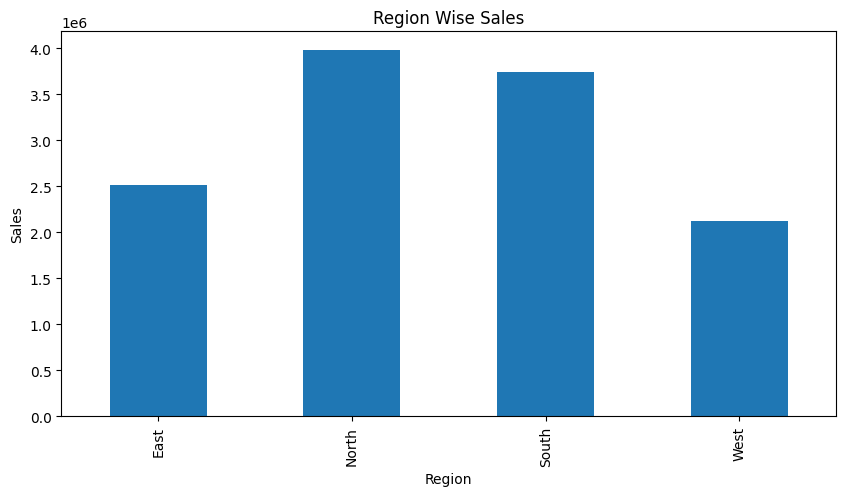

In [12]:
# Region Wise Sales

region_sales = sales_df.groupby('Region')['Total_Sales'].sum()

region_sales.plot(kind='bar', figsize=(10,5))

plt.title("Region Wise Sales")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

In [13]:
# Save Models

import joblib

joblib.dump(churn_model, "deployment/model.pkl")

joblib.dump(scaler, "deployment/scaler.pkl")

print("Models Saved Successfully")

Models Saved Successfully
